# Image Features and Image Alignment

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import sys
import os

In [7]:
filepath = "C:/Users/pc/Documents/A My Program/A Machine Learning/opencv-python-free-course-code/08_Image_Fetaures_and_Alignment"
os.chdir(filepath)

In [8]:
ref_filename = "form.jpg"
print("Reference Image: ", ref_filename)
im1 = cv2.imread(ref_filename, cv2.IMREAD_COLOR)
im1 = cv2.cvtColor(im1, cv2.COLOR_BGR2RGB)

im_filename = "scanned-form.jpg"
print("Scanned Image: ", im_filename)
im2 = cv2.imread(im_filename, cv2.IMREAD_COLOR)
im2 = cv2.cvtColor(im2, cv2.COLOR_BGR2RGB)

Reference Image:  form.jpg
Scanned Image:  scanned-form.jpg


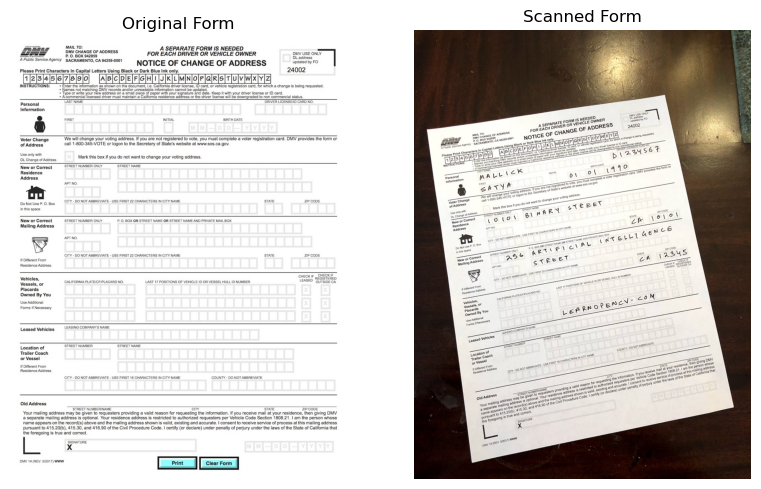

In [9]:
plt.figure(figsize=[20, 10])
plt.subplot(141); plt.axis("off"); plt.imshow(im1); plt.title("Original Form")
plt.subplot(142); plt.axis("off"); plt.imshow(im2); plt.title("Scanned Form")
plt.show()

In [10]:
im1_gray = cv2.cvtColor(im1, cv2.COLOR_BGR2GRAY)
im2_gray = cv2.cvtColor(im2, cv2.COLOR_BGR2GRAY)

MAX_NUM_FEATURES = 500
orb = cv2.ORB_create(MAX_NUM_FEATURES)
keypoints1, descriptors1 = orb.detectAndCompute(im1_gray, None)
keypoints2, descriptors2 = orb.detectAndCompute(im2_gray, None)

im1_display = cv2.drawKeypoints(im1, keypoints1, outImage=np.array([]), color=(255, 0,0), flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
im2_display = cv2.drawKeypoints(im2, keypoints2, outImage=np.array([]), color=(255, 0,0), flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

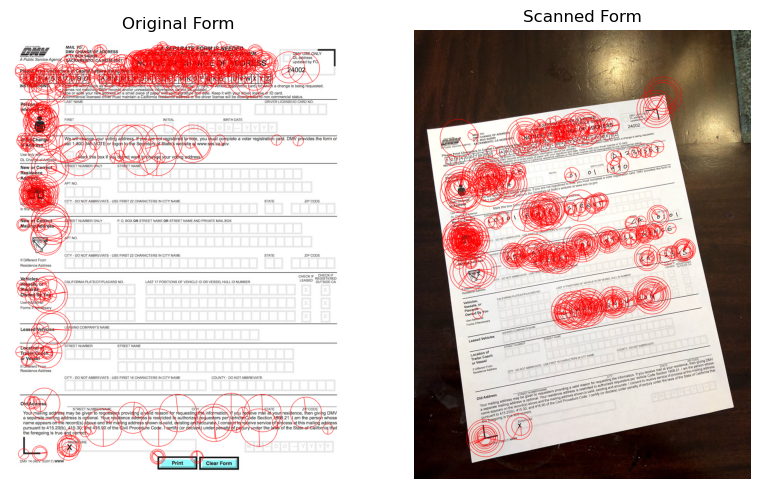

In [11]:
plt.figure(figsize=[20, 10])
plt.subplot(141); plt.axis("off"); plt.imshow(im1_display); plt.title("Original Form")
plt.subplot(142); plt.axis("off"); plt.imshow(im2_display); plt.title("Scanned Form")
plt.show()

In [14]:
matcher = cv2.DescriptorMatcher_create(cv2.DESCRIPTOR_MATCHER_BRUTEFORCE_HAMMING)
matches = matcher.match(descriptors1, descriptors2, None)
matches = list(matches)

matches.sort(key=lambda x: x.distance, reverse=False)

numGoodMatches = int(len(matches) * 0.1)
matches = matches[:numGoodMatches]

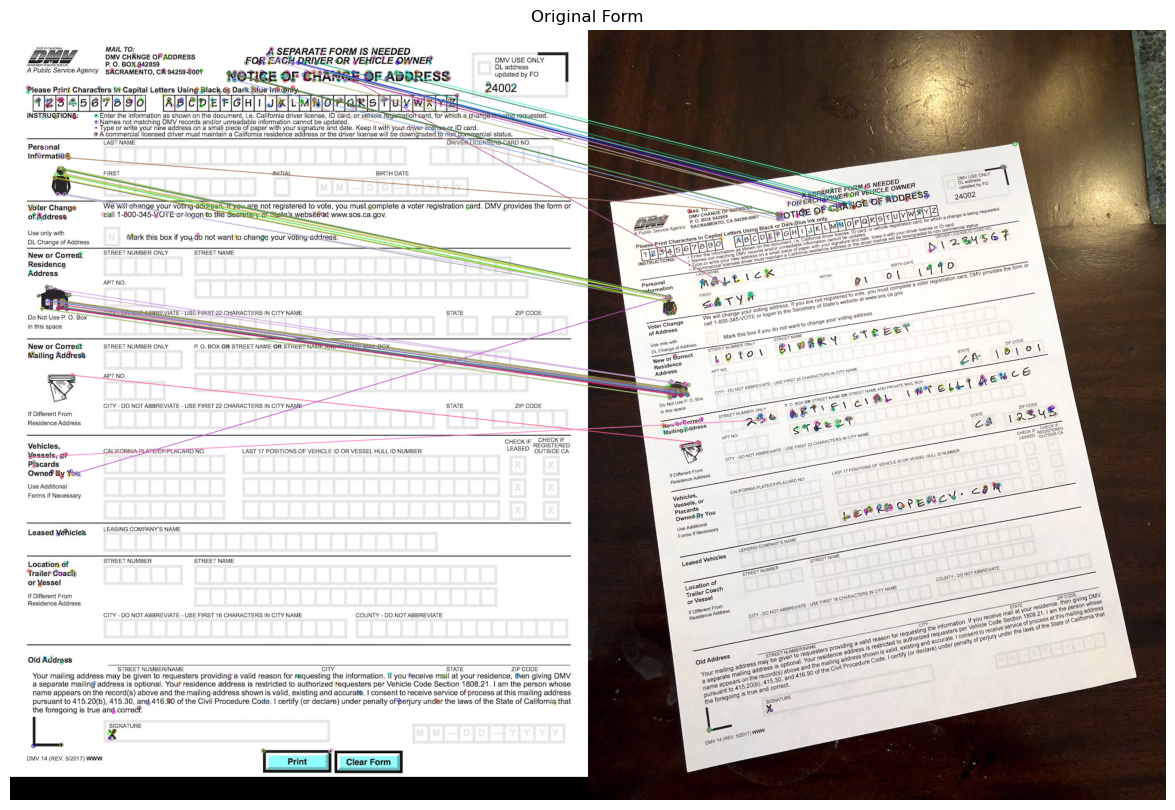

In [15]:
im_matches = cv2.drawMatches(im1, keypoints1, im2, keypoints2, matches, None)

plt.figure(figsize=[40, 10])
plt.imshow(im_matches); plt.axis("off"); plt.title("Original Form");
plt.show()

In [22]:
points1 = np.zeros((len(matches), 2), dtype=np.float32)
points2 = np.zeros((len(matches), 2), dtype=np.float32)

for i, match in enumerate(matches):
    points1[i, :] = keypoints1[match.queryIdx].pt
    points2[i, :] = keypoints2[match.trainIdx].pt

h, mask = cv2.findHomography(points2, points1, cv2.RANSAC)

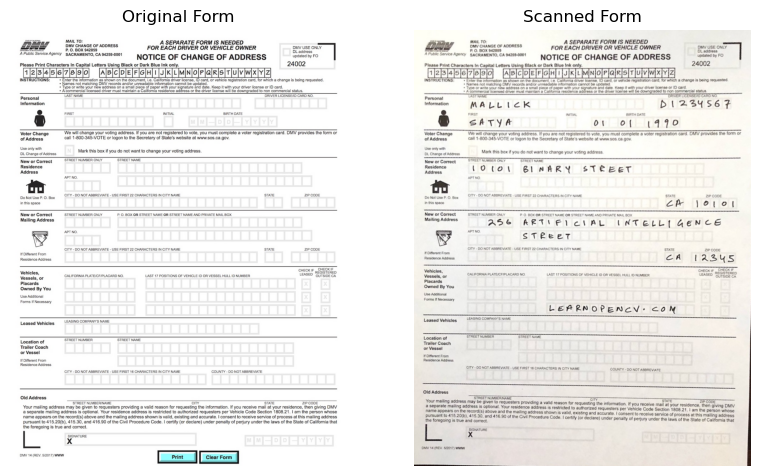

In [23]:
height, width, channels = im1.shape
im2_reg = cv2.warpPerspective(im2, h, (width, height))

plt.figure(figsize=[20, 10])
plt.subplot(141); plt.imshow(im1); plt.axis("off"); plt.title("Original Form");
plt.subplot(142); plt.imshow(im2_reg); plt.axis("off"); plt.title("Scanned Form");
plt.show()

# Image Stiching and Creating Panorama

In [25]:
import cv2
import glob
import matplotlib.pyplot as plt 
%matplotlib inline
import math
import os

In [27]:
filepath = "C:\\Users\\pc\\Documents\\A My Program\\A Machine Learning\\opencv-python-free-course-code\\09_Panorama"
os.chdir(filepath)

In [28]:
imagefiles= glob.glob("boat/*")
imagefiles.sort()

images= []
for filename in imagefiles:
    img = cv2.imread(filename)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    images.append(img)

num_images = len(images)

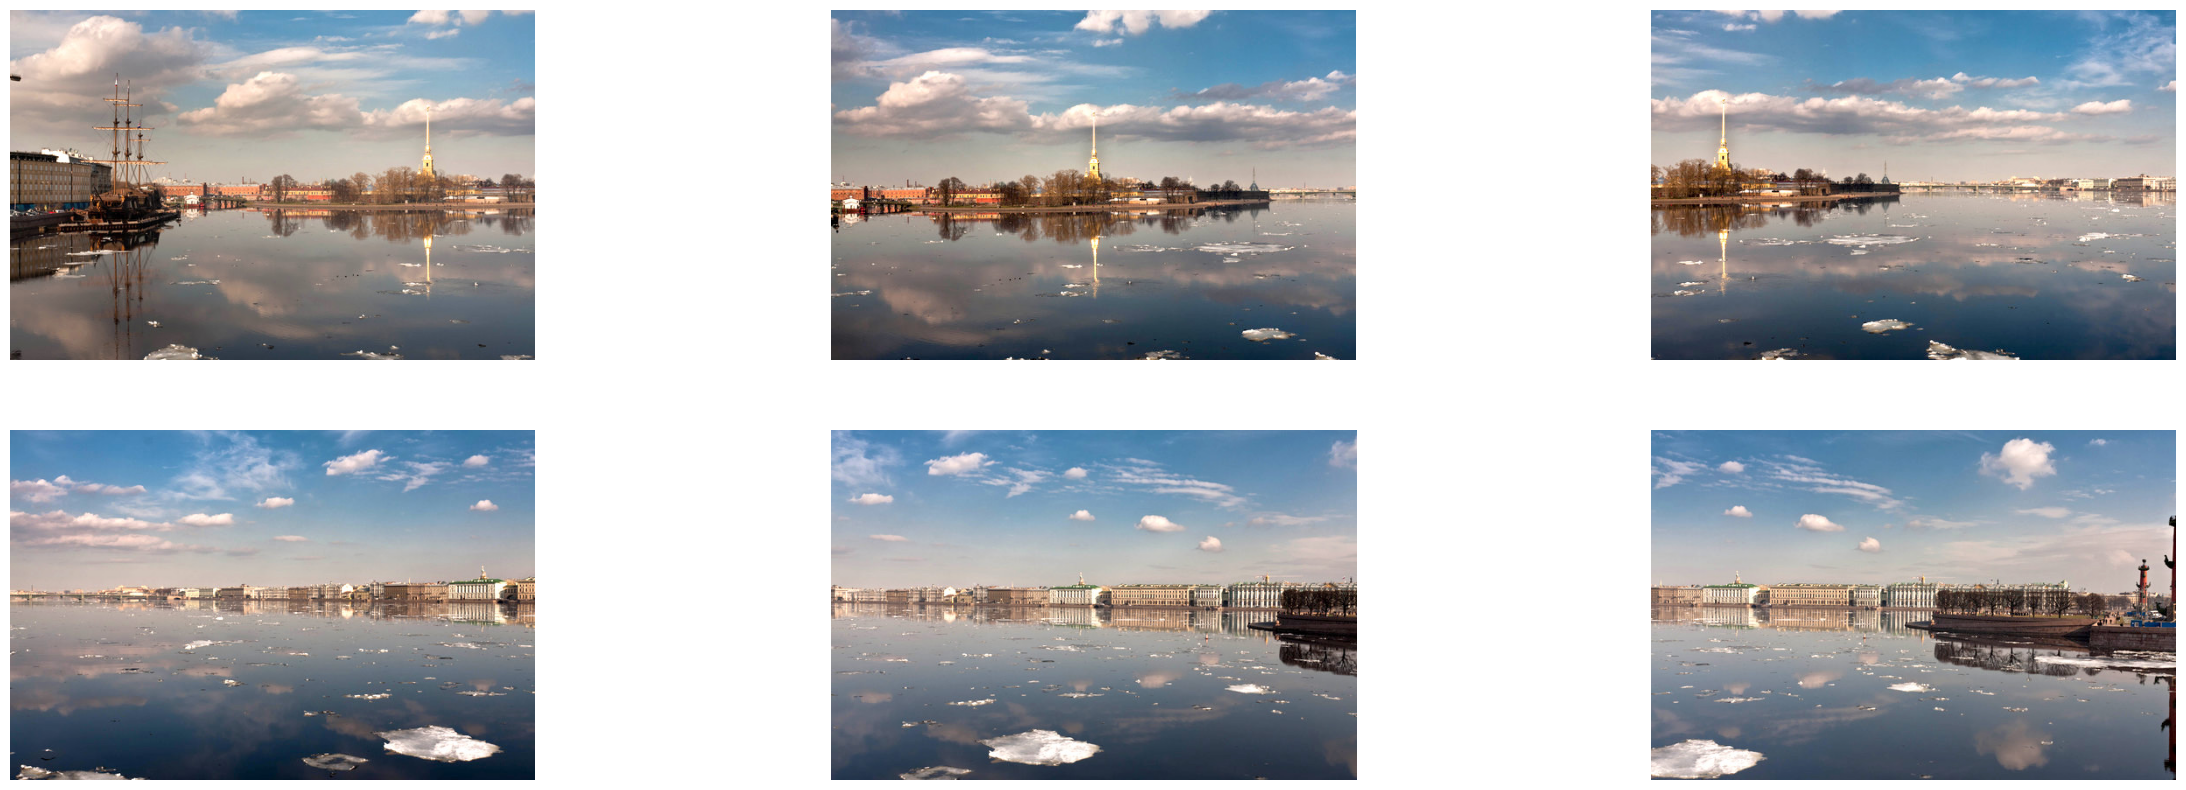

In [29]:
plt.figure(figsize=[30,10])
num_cols =3
num_rows = math.ceil(num_images / num_cols)

for i in range(0, num_images):
    plt.subplot(num_rows, num_cols, i+1);
    plt.axis("off")
    plt.imshow(images[i])
plt.show()

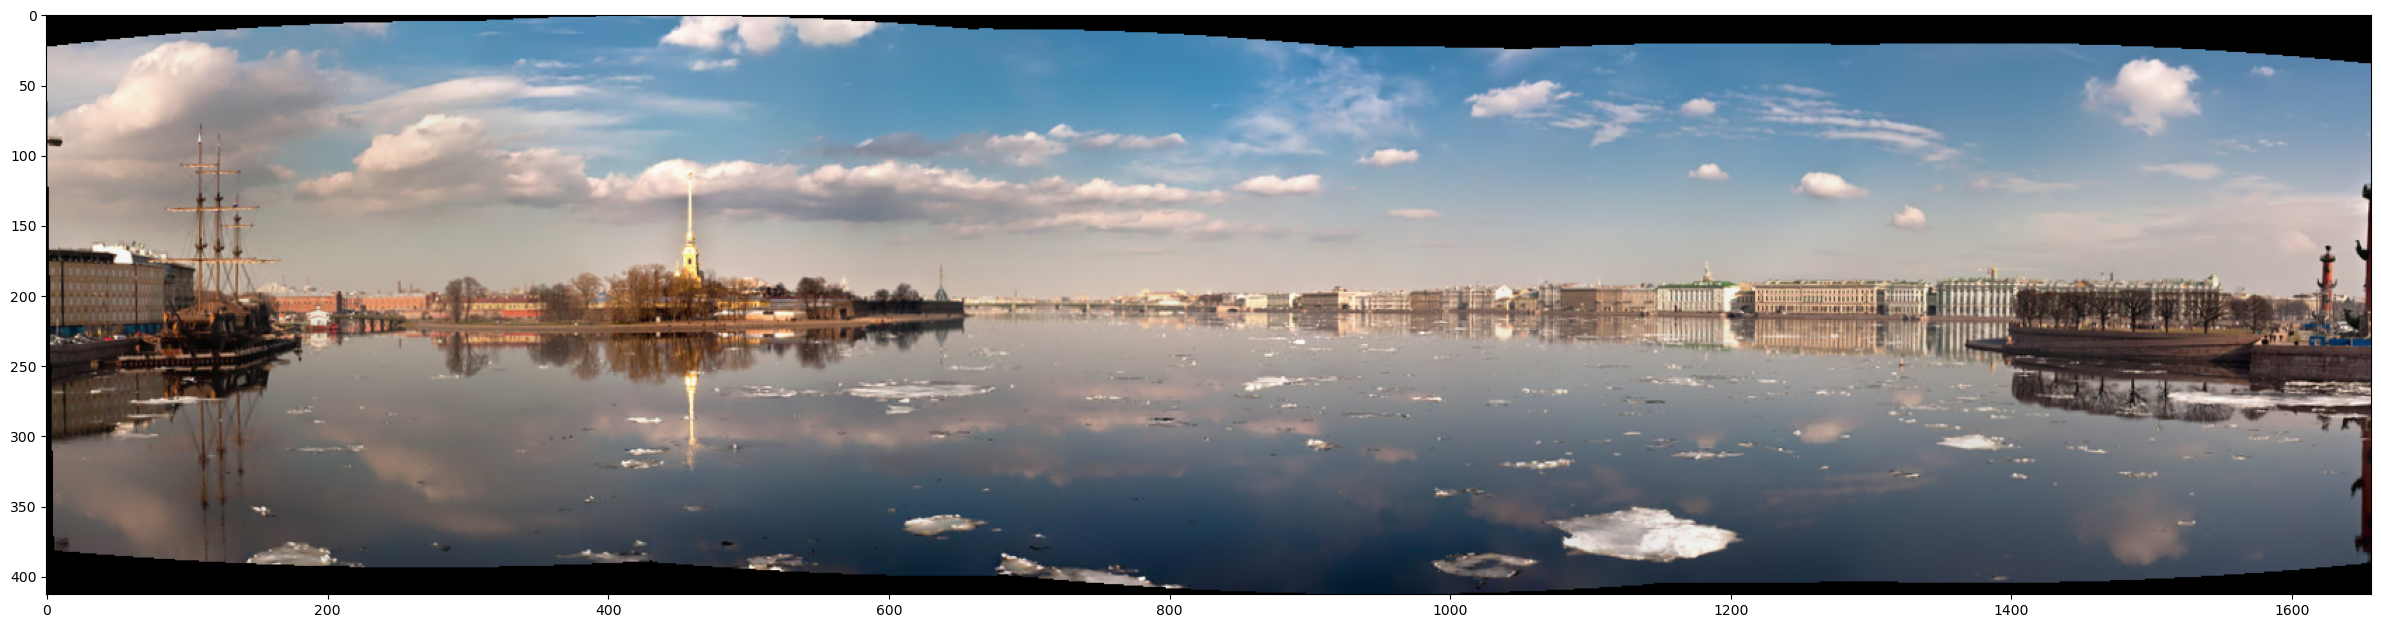

In [31]:
stitcher = cv2.Stitcher_create()
status, result = stitcher.stitch(images)
if status == 0:
    plt.figure(figsize=[30,10])
    plt.imshow(result)
plt.show()

# Image High Dynamic Range (HDR)

In [5]:
import os
filepath = "C:\\Users\\pc\\Documents\\A My Program\\A Machine Learning\\opencv-python-free-course-code\\10_HDR"
os.chdir(filepath)

In [6]:
img_hdr = cv2.imread("high-dynamic-range-hdr.jpg", cv2.IMREAD_COLOR)
img_hdr = cv2.cvtColor(img_hdr, cv2.COLOR_BGR2RGB)

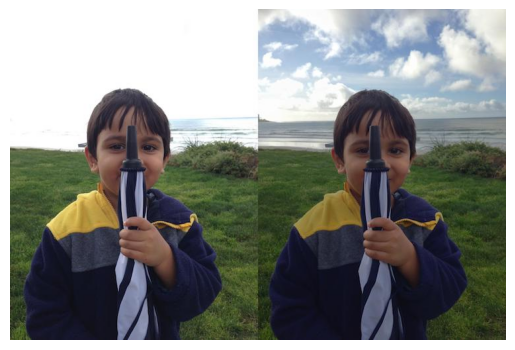

In [7]:
plt.imshow(img_hdr); plt.axis('off'); plt.show()

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [9]:
def readImagesAndTimes():
    filenames = ["img_0.033.jpg", "img_0.25.jpg", "img_2.5.jpg", "img_15.jpg"]
    times = np.array([1/30.0, 0.25, 2.5, 15.0], dtype=np.float32)

    images = []
    for filename in filenames:
        im = cv2.imread(filename)
        im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
        images.append(im)
    return images, times

In [10]:
images, times = readImagesAndTimes()
alignMTB = cv2.createAlignMTB()
alignMTB.process(images, images)

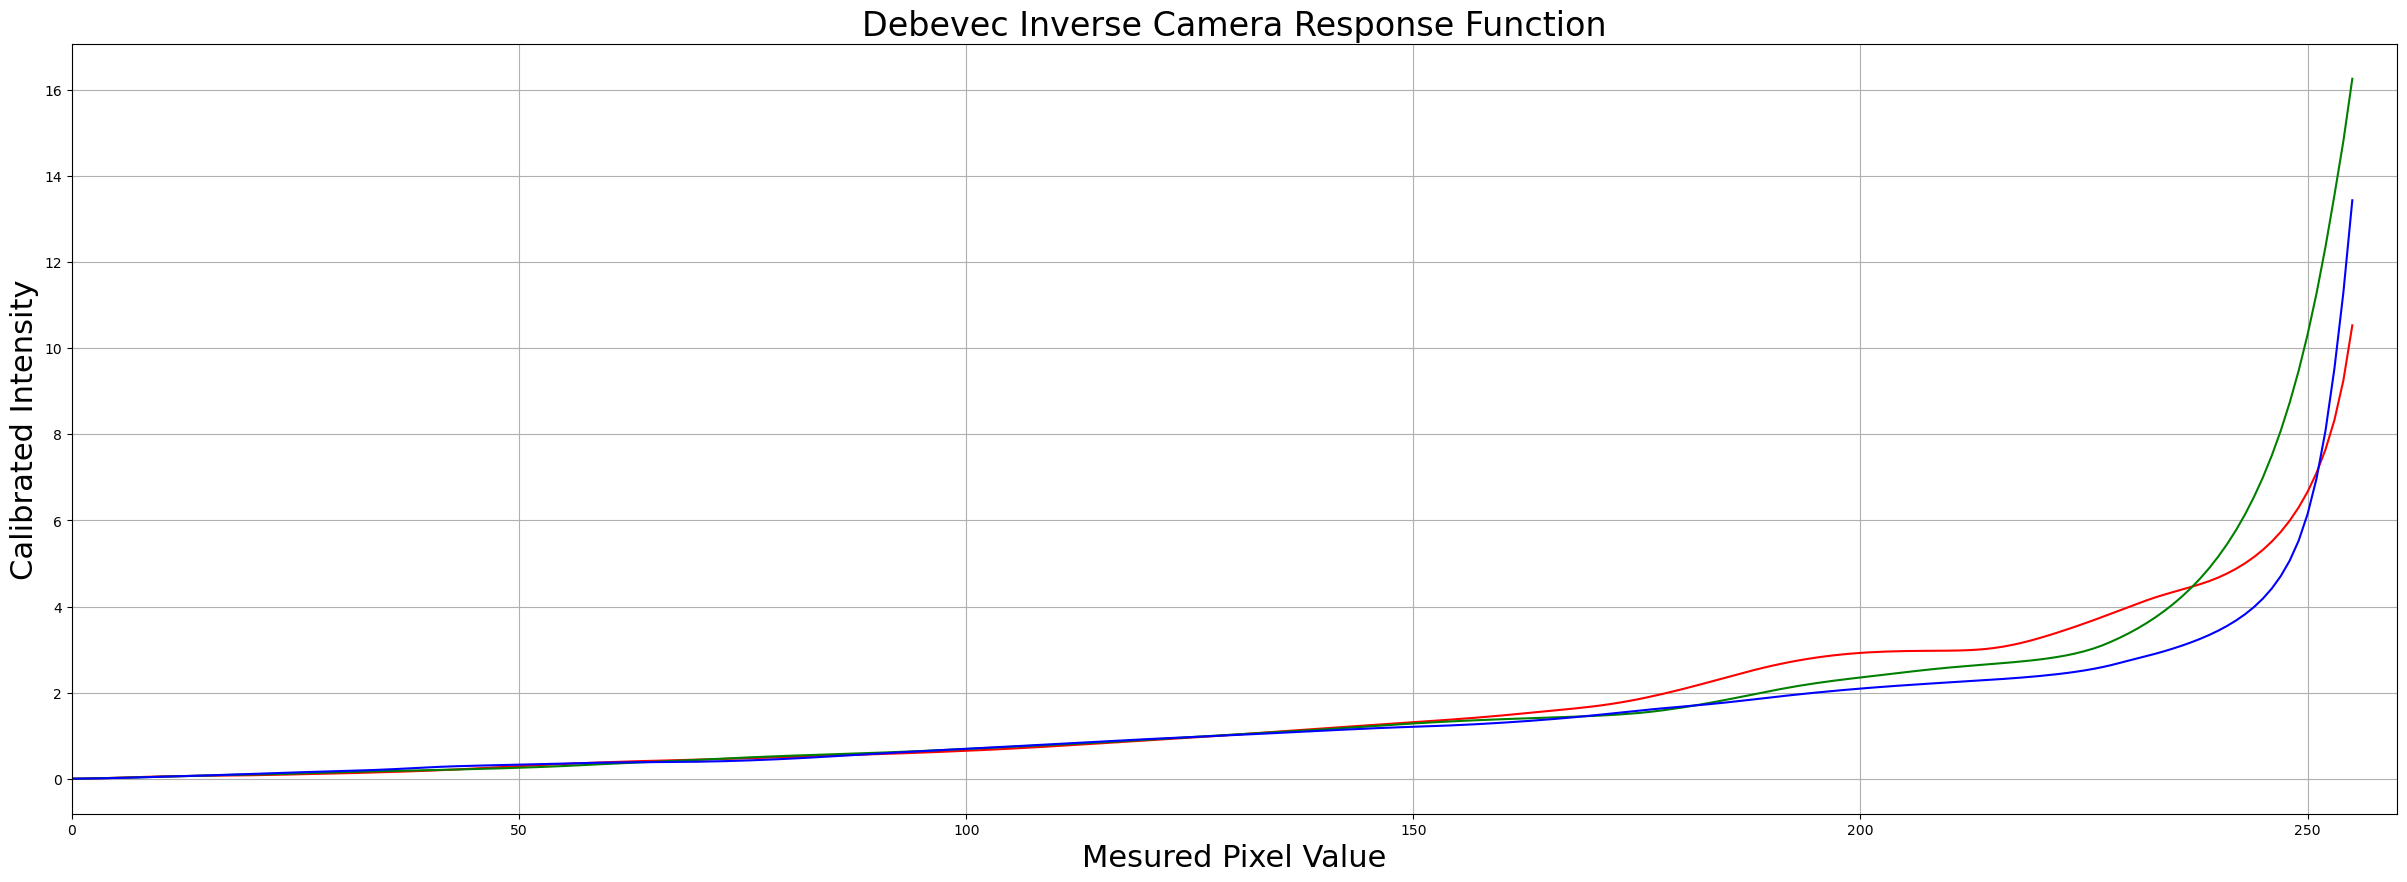

In [14]:
calibrateDebevec = cv2.createCalibrateDebevec()
responseDebevec = calibrateDebevec.process(images, times)

x = np.arange(256, dtype=np.uint8)
y = np.squeeze(responseDebevec)

ax = plt.figure(figsize=[30,10])
plt.title("Debevec Inverse Camera Response Function", fontsize=24)
plt.xlabel("Mesured Pixel Value", fontsize=22)
plt.ylabel("Calibrated Intensity", fontsize=22)
plt.xlim([0, 260])
plt.grid()
plt.plot(x, y[:,0], 'r', x, y[:,1], 'g', x, y[:,2], 'b')
plt.show()

In [15]:
mergeDebevec = cv2.createMergeDebevec()
hdrDebevec = mergeDebevec.process(images, times, responseDebevec)

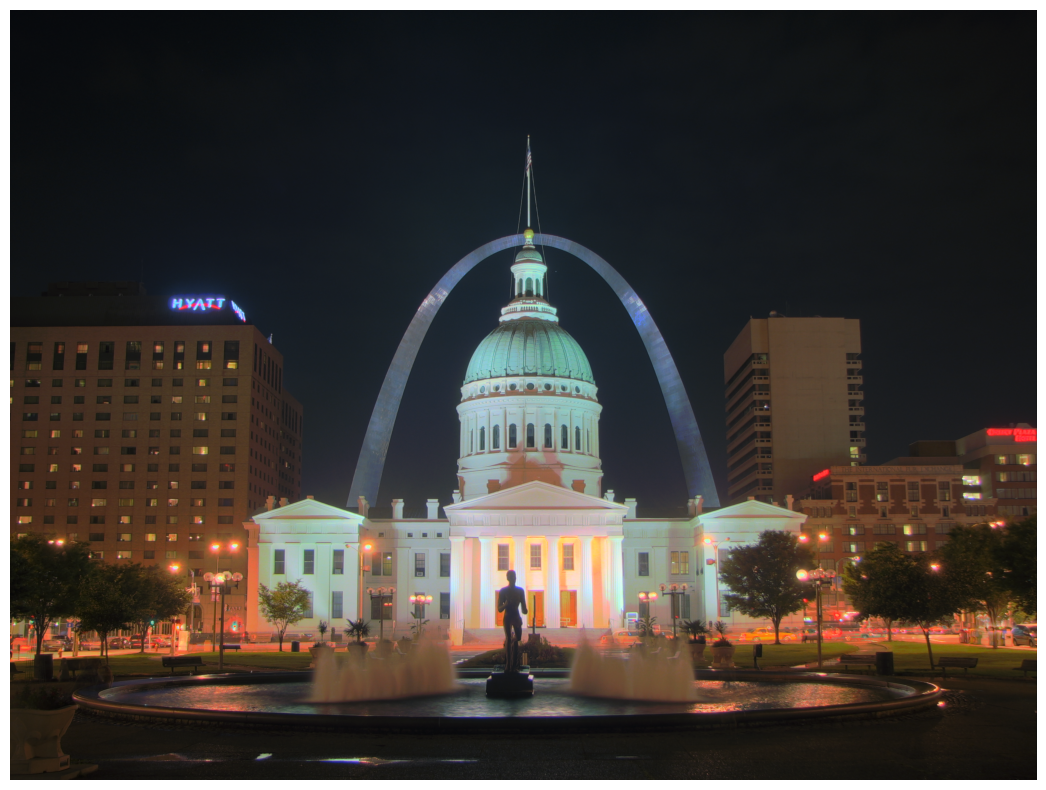

In [16]:
tonemapDrago = cv2.createTonemapDrago(1.0, 0.7)
ldrDrago = tonemapDrago.process(hdrDebevec)
ldrDrago = 3 * ldrDrago
plt.figure(figsize=[20,10]); plt.imshow(np.clip(ldrDrago, 0, 1)); plt.axis("off");
plt.show()